2026-03-30 18:27:18.543704: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774895238.753226      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774895238.815363      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774895239.341073      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774895239.341125      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774895239.341128      55 computation_placer.cc:177] computation placer alr

Total patients: 281
Indexing volumes for Training...
Indexing volumes for Testing...


I0000 00:00:1774895378.663367      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774895378.669367      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Training 3D DenseNet...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1774895392.399514     133 service.cc:152] XLA service 0x7cbd1c0275e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774895392.399555     133 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774895392.399563     133 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774895392.993546     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/224 ━━━━━━━━━━━━━━━━━━━━ 39:01 11s/step - accuracy: 0.5000 - auc: 0.0000e+00 - loss: 0.7616

I0000 00:00:1774895396.491632     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


224/224 ━━━━━━━━━━━━━━━━━━━━ 443s 2s/step - accuracy: 0.7032 - auc: 0.7707 - loss: 0.5594 - val_accuracy: 0.7719 - val_auc: 0.8596 - val_loss: 0.6810
Epoch 2/5
224/224 ━━━━━━━━━━━━━━━━━━━━ 84s 375ms/step - accuracy: 0.7640 - auc: 0.8457 - loss: 0.4870 - val_accuracy: 0.8158 - val_auc: 0.9264 - val_loss: 0.4489
Epoch 3/5
224/224 ━━━━━━━━━━━━━━━━━━━━ 53s 237ms/step - accuracy: 0.7963 - auc: 0.8682 - loss: 0.4432 - val_accuracy: 0.8596 - val_auc: 0.9375 - val_loss: 0.3371
Epoch 4/5
224/224 ━━━━━━━━━━━━━━━━━━━━ 47s 210ms/step - accuracy: 0.8156 - auc: 0.8680 - loss: 0.4514 - val_accuracy: 0.8333 - val_auc: 0.9383 - val_loss: 0.3390
Epoch 5/5
224/224 ━━━━━━━━━━━━━━━━━━━━ 46s 204ms/step - accuracy: 0.8372 - auc: 0.8777 - loss: 0.4243 - val_accuracy: 0.8421 - val_auc: 0.9372 - val_loss: 0.3258


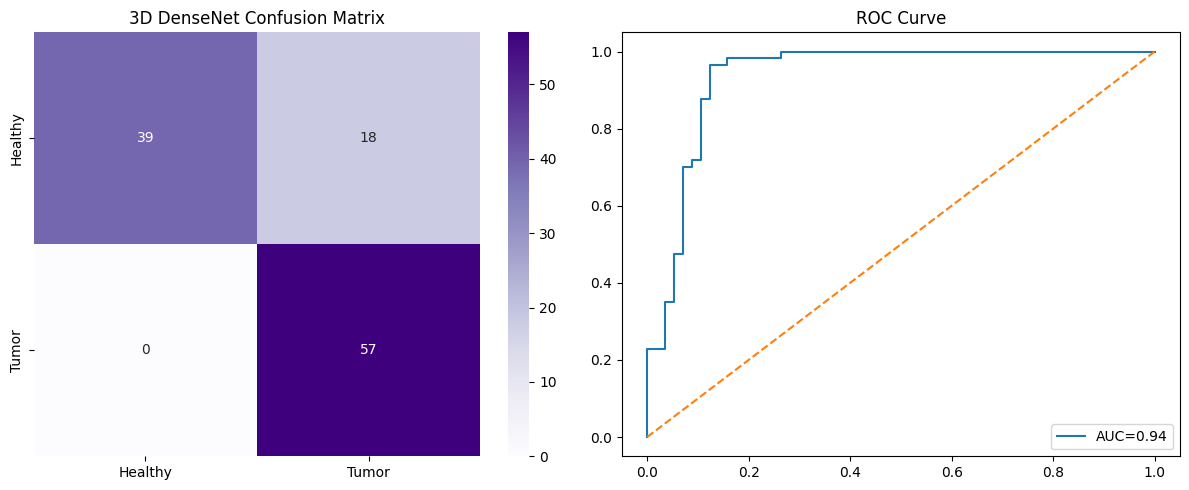

              precision    recall  f1-score   support

         0.0       1.00      0.68      0.81        57
         1.0       0.76      1.00      0.86        57

    accuracy                           0.84       114
   macro avg       0.88      0.84      0.84       114
weighted avg       0.88      0.84      0.84       114

AUC: 0.9369
✅ Model saved as 3d_densenet_pancreas.h5


In [1]:
# ================= INSTALL =================
!pip install nibabel tensorflow seaborn -q

# ================= IMPORTS =================
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import Input, Conv3D, GlobalAveragePooling3D, Dense, Dropout, BatchNormalization, Activation, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# ================= CONFIG =================
PATCH_SIZE = 64
BATCH_SIZE = 2
EPOCHS = 5
BASE_PATH = "/kaggle/input/datasets/rksrank1/pancreatic-cancer/Task07_Pancreas"
IMAGE_DIR = os.path.join(BASE_PATH, "imagesTr")
MASK_DIR = os.path.join(BASE_PATH, "labelsTr")

# ================= DATA SEQUENCE =================
class Pancreas3DPatchSequence(Sequence):
    def __init__(self, patient_files, batch_size=BATCH_SIZE, is_training=True):
        self.patient_files = patient_files
        self.batch_size = batch_size
        self.is_training = is_training
        self.samples = self._prepare_samples()

    def _prepare_samples(self):
        samples = []
        print(f"Indexing volumes for {'Training' if self.is_training else 'Testing'}...")
        for file in self.patient_files:
            if file.startswith("._"): 
                continue
            mask_path = os.path.join(MASK_DIR, file)
            if not os.path.exists(mask_path): 
                continue

            mask_vol = nib.load(mask_path).get_fdata()
            tumor_indices = np.argwhere(mask_vol == 2)

            if len(tumor_indices) > 0:
                # Tumor sample
                rand_idx = np.random.randint(len(tumor_indices))
                tumor_center = tumor_indices[rand_idx]
                samples.append((file, tumor_center, 1))

                # Random healthy point
                h, w, d = mask_vol.shape
                while True:
                    rand_point = [np.random.randint(0,h), np.random.randint(0,w), np.random.randint(0,d)]
                    if mask_vol[tuple(rand_point)] == 0:
                        break
                samples.append((file, rand_point, 0))

        np.random.shuffle(samples)
        return samples

    def __len__(self):
        return int(np.ceil(len(self.samples)/self.batch_size))

    def __getitem__(self, idx):
        batch = self.samples[idx*self.batch_size:(idx+1)*self.batch_size]
        X, y = [], []
        for file, center, label in batch:
            img_vol = nib.load(os.path.join(IMAGE_DIR,file)).get_fdata()
            z_c, y_c, x_c = [int(c) for c in center]

            # Extract 3D patch
            z_s, y_s, x_s = max(0,z_c-PATCH_SIZE//2), max(0,y_c-PATCH_SIZE//2), max(0,x_c-PATCH_SIZE//2)
            patch = img_vol[z_s:z_s+PATCH_SIZE, y_s:y_s+PATCH_SIZE, x_s:x_s+PATCH_SIZE]

            # Pad if smaller than PATCH_SIZE
            if patch.shape != (PATCH_SIZE, PATCH_SIZE, PATCH_SIZE):
                patch = np.pad(patch, [(0, PATCH_SIZE - patch.shape[0]),
                                       (0, PATCH_SIZE - patch.shape[1]),
                                       (0, PATCH_SIZE - patch.shape[2])], mode='constant')

            # Normalize CT intensities
            patch = np.clip(patch, -100, 200)
            patch = (patch + 100)/300.0

            X.append(patch[..., np.newaxis])
            y.append(label)
        return np.array(X, dtype='float32'), np.array(y, dtype='float32')

# ================= 3D DenseNet Model =================
def build_3d_densenet():
    inputs = Input((PATCH_SIZE,PATCH_SIZE,PATCH_SIZE,1))
    x = Conv3D(16,3,strides=2,padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Dense blocks
    for _ in range(2):
        shortcut = x
        x = BatchNormalization()(x)
        x = Activation('relu')(x)
        x = Conv3D(16,3,padding='same')(x)
        x = Concatenate()([x, shortcut])

    x = GlobalAveragePooling3D()(x)
    x = Dropout(0.4)(x)
    outputs = Dense(1,activation='sigmoid')(x)

    model = Model(inputs,outputs)
    model.compile(optimizer=Adam(1e-4), loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

# ================= LOAD FILES =================
all_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith((".nii",".nii.gz")) and not f.startswith(".")])
print(f"Total patients: {len(all_files)}")
train_files, test_files = train_test_split(all_files, test_size=0.2, random_state=42)

train_seq = Pancreas3DPatchSequence(train_files)
test_seq = Pancreas3DPatchSequence(test_files, is_training=False)

# ================= TRAIN =================
model_dense = build_3d_densenet()
print("Training 3D DenseNet...")
model_dense.fit(train_seq, validation_data=test_seq, epochs=EPOCHS)

# ================= EVALUATION =================
y_true, y_probs = [], []
for i in range(len(test_seq)):
    xb, yb = test_seq[i]
    preds = model_dense.predict(xb, verbose=0)
    y_true.extend(yb)
    y_probs.extend(preds.flatten())

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred = (y_probs>0.5).astype(int)

# ================= PLOTS =================
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Healthy','Tumor'], yticklabels=['Healthy','Tumor'])
plt.title('3D DenseNet Confusion Matrix')

plt.subplot(1,2,2)
plt.plot(fpr,tpr,label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title('ROC Curve')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred))
print(f"AUC: {roc_auc:.4f}")

# ================= SAVE MODEL =================
model_dense.save("3d_densenet_pancreas.h5")
print("✅ Model saved as 3d_densenet_pancreas.h5")